In [7]:
# Notes:
# The stock plots show training data, not out-of-sample data.
# Not all oos data needed to create these plots are stored in compute_score.
# Factor models are not plotted correctly - would require a compute_score update.

In [8]:
# Import modules 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.metrics import adjusted_rand_score as _ARI
import pickle
from fractions import Fraction
from gridsearch import import_data, import_factors, compute_score

In [9]:
# Import data

data_excel = "/Users/chrismader/Python/SLDS/Data/bbg_data.xlsx"
results_csv = "/Users/chrismader/Python/SLDS/DRO/gridsearch_results.csv"
segments_parquet = "/Users/chrismader/Python/SLDS/DRO/gridsearch_segments.parquet"
ff_dir = "/Users/chrismader/Python/SLDS/Data/"
ff_files = {
    "ff5": "F-F_Research_Data_5_Factors_2x3_daily.csv",
    "ff3": "F-F_Research_Data_Factors_daily.csv",
    "mom": "F-F_Momentum_Factor_daily.csv",}

px_all, eps_all, pe_all, ser_vix = import_data(data_excel)
ff = import_factors(ff_dir, ff_files)
ff = ff.loc[px_all.index.min(): px_all.index.max(), :]
ff = ff.div(100)

In [10]:
# CONFIG

start_date = "2017"
end_date = None

mode = "fund"   # px, fund, factor

# config = "[y]"
# n_regimes = 6
# dim_latent = 1

config = "[g,v]"
n_regimes = 6
dim_latent = 2

# config = "factor2_ff3"
# n_regimes = 4
# dim_latent = 3

value_sel = "cagr_rel"

In [11]:
# Best and worst performing stocks

res = pd.read_csv(results_csv)

subset = res[
    (res["config"] == config) &
    (res["n_regimes"] == n_regimes) &
    (res["dim_latent"] == dim_latent)]

# Exclude +/- inf and NaN
subset = (subset
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[value_sel]))

# Top N
n = 75
topN = (
    subset
    .nlargest(n, value_sel)[["security", value_sel]]
    .assign(**{value_sel: lambda df: df[value_sel].round(3)}))
print(f"Top {n}:")
print(topN.to_string(index=False))

# Worst N
bottomN = (
    subset
    .nsmallest(n, value_sel)[["security", value_sel]]
    .assign(**{value_sel: lambda df: df[value_sel].round(3)}))
print(f"\nWorst {n}:")
print(bottomN.to_string(index=False))


Top 75:
security  cagr_rel
      BA     0.118
     XOM     0.072
     WFC     0.065
     CVX     0.062
      GE     0.046
    META     0.043
    ADBE     0.039
       D     0.035
    CSCO     0.035
       D     0.032
    ISRG     0.032
     MRK     0.031
    NFLX     0.030
       C     0.026
       T     0.026
     CRM     0.025
    QCOM     0.024
    SCHW     0.023
     TMO     0.021
     TMO     0.021
     DUK     0.021
     PEP     0.020
    BKNG     0.020
     BAC     0.018
      PM     0.018
       O     0.018
     PLD     0.018
     CAT     0.016
     AEP     0.015
     BLK     0.015
     UNH     0.015
      VZ     0.013
     IBM     0.012
     HON     0.011
    AMGN     0.011
    NVDA     0.011
    ABBV     0.010
    AAPL     0.006
     JNJ     0.006
    CBRE     0.004
     JPM     0.004
      SO     0.004
     AMD     0.003
     MCD     0.003
      GS     0.003
     BSX     0.003
   GOOGL     0.002
   GOOGL     0.001
      KO     0.000
     NEE    -0.001
    COST    -0.001
    

In [12]:
# Plotting functions

COLOR_STRAT = "#444444"  # dark grey
# COLOR_BENCH = "#ff7f0e"  # orange
COLOR_BENCH = "#1f77b4"  # blue

_RES_CACHE = {}
_SEG_CACHE = {}

def _load_results(results_path: str) -> pd.DataFrame:
    df = _RES_CACHE.get(results_path)
    if df is None:
        df = pd.read_csv(results_path)
        _RES_CACHE[results_path] = df
    return df

def _load_segments(segments_path: str) -> pd.DataFrame:
    df = _SEG_CACHE.get(segments_path)
    if df is None:
        df = pd.read_parquet(segments_path)
        _SEG_CACHE[segments_path] = df
    return df

def _select_model_row(res: pd.DataFrame, security, config, n_regimes, dim_latent):
    row = res[
        (res["security"] == security)
        & (res["config"] == config)
        & (res["n_regimes"] == n_regimes)
        & (res["dim_latent"].astype(str) == str(dim_latent))
    ]
    if row.empty:
        raise ValueError(
            f"No matching rows in results CSV for "
            f"security={security}, config={config}, "
            f"n_regimes={n_regimes}, dim_latent={dim_latent}"
        )
    return row.iloc[0]

def _filter_segments_for_model(seg: pd.DataFrame, security, config, n_regimes, dim_latent):
    seg = seg[
        (seg["security"] == security)
        & (seg["config"] == config)
        & (seg["n_regimes"] == n_regimes)
        & (seg["dim_latent"].astype(str) == str(dim_latent))
    ]
    if seg.empty:
        raise ValueError("No matching rows found in segments parquet for this model selection.")
    return seg.sort_values("date")

def _parse_dt(dt_val):
    # dt stored as "1/252" or numeric
    if isinstance(dt_val, str):
        dt_val = dt_val.strip()
        if "/" in dt_val:
            return float(Fraction(dt_val))
        return float(dt_val)
    return float(dt_val)


def _infer_regime_signals_from_index(px, z, strat_index):
    """
    Infer regime -> {0,1} mapping used inside compute_score from the realized
    strategy index and benchmark returns.
    """
    bench_ret = px.pct_change().fillna(0)
    z = np.asarray(z)
    sig_map = {}

    for r in np.unique(z):
        idx_r = np.where(z == r)[0]
        ws = []
        for t in idx_r:
            if t == 0:
                continue
            br = float(bench_ret.iloc[t])
            if br == 0.0:
                continue
            si_prev = float(strat_index.iloc[t - 1])
            si_curr = float(strat_index.iloc[t])
            if si_prev <= 0:
                continue
            g = si_curr / si_prev - 1.0
            w = g / br
            if np.isfinite(w):
                ws.append(w)

        if not ws:
            sig = 0
        else:
            m = np.median(ws)
            sig = 1 if m > 0.5 else 0
        sig_map[r] = sig

    return sig_map

def _compute_cagr_and_series(
    results_csv,
    segments_parquet,
    security,
    config,
    n_regimes,
    dim_latent,
    atol=1e-12,
    rtol=1e-12,
):
    """
    Core computation for a given (security, model):
      - loads results/segments
      - aligns with px_all
      - computes cagr_rel/strat/bench and strat/bench indices
      - infers regime signals.
    Returns dict with everything needed for plotting.
    """
    res = _load_results(results_csv)
    row = _select_model_row(res, security, config, n_regimes, dim_latent)

    if "cagr_rel" not in row or pd.isna(row["cagr_rel"]):
        raise ValueError("cagr_rel missing in results CSV for this row.")

    cagr_rel_stored = float(row["cagr_rel"])
    dt = _parse_dt(row["dt"])

    # Segments
    seg = _load_segments(segments_parquet)
    seg = _filter_segments_for_model(seg, security, config, n_regimes, dim_latent)

    z = seg["z"].to_numpy()
    dates = pd.to_datetime(seg["date"].to_numpy())

    # Prices
    if security not in px_all.columns:
        raise ValueError(f"Security {security} not found in price panel.")
    px_full = px_all[security].dropna()
    idx = px_full.index.intersection(dates)
    if len(idx) == 0:
        raise ValueError("No overlapping dates between prices and segments.")
    idx = idx.sort_values()

    px = px_full.loc[idx]
    seg_aligned = seg.set_index(pd.to_datetime(seg["date"])).loc[idx]
    z_aligned = seg_aligned["z"].to_numpy()

    if len(z_aligned) != len(px):
        raise ValueError(
            f"Length mismatch after alignment: len(px)={len(px)}, len(z)={len(z_aligned)}"
        )

    # Performance
    cagr_rel, cagr_strat, cagr_bench, strat_index, bench_index, _ = compute_score(
        px, z_aligned, dt
    )

    # Consistency check
    if not np.isclose(cagr_rel, cagr_rel_stored, rtol=rtol, atol=atol):
        raise ValueError(
            f"Recomputed cagr_rel_cusum={cagr_rel:.3} "
            f"!= stored {cagr_rel_stored:.3}"
        )

    strat_index = pd.Series(strat_index, index=px.index)
    bench_index = pd.Series(bench_index, index=px.index)

    # Regime → signal
    sig_map = _infer_regime_signals_from_index(px, z_aligned, strat_index)

    return {
        "px": px,
        "z": z_aligned,
        "strat_index": strat_index,
        "bench_index": bench_index,
        "sig_map": sig_map,
        "cagr_rel": cagr_rel,
        "cagr_strat": cagr_strat,
        "cagr_bench": cagr_bench,
        "dt": dt,
    }

def plot_cagr(
    results_csv,
    segments_parquet,
    data_excel,
    security,
    config,
    n_regimes,
    dim_latent,
    start_date=None,
    end_date=None,
    atol=1e-12,
    rtol=1e-12,
):
    core = _compute_cagr_and_series(
        results_csv=results_csv,
        segments_parquet=segments_parquet,
        security=security,
        config=config,
        n_regimes=n_regimes,
        dim_latent=dim_latent,
        atol=atol,
        rtol=rtol,
    )

    px = core["px"]
    z_aligned = core["z"]
    strat_index = core["strat_index"]
    bench_index = core["bench_index"]
    sig_map = core["sig_map"]
    cagr_rel = core["cagr_rel"]
    cagr_strat = core["cagr_strat"]
    cagr_bench = core["cagr_bench"]

    # Select plotting window
    if start_date is not None or end_date is not None:
        start = pd.to_datetime(start_date) if start_date is not None else px.index[0]
        end = pd.to_datetime(end_date) if end_date is not None else px.index[-1]

        mask = (px.index >= start) & (px.index <= end)
        if mask.sum() < 2:
            raise ValueError("Insufficient data in requested date range for plotting.")

        px_plot = px.loc[mask]
        strat_plot = strat_index.loc[mask]
        bench_plot = bench_index.loc[mask]
        z_plot = z_aligned[mask]
    else:
        px_plot = px
        strat_plot = strat_index
        bench_plot = bench_index
        z_plot = z_aligned

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    ax.plot(px_plot.index, bench_plot, label="Benchmark index", color=COLOR_BENCH)
    ax.plot(px_plot.index, strat_plot, label="Strategy index", color=COLOR_STRAT)

    ymin, ymax = ax.get_ylim()
    used_labels = set()
    for regime in np.unique(z_plot):
        mask_reg = (z_plot == regime)
        sig = sig_map.get(regime, 0)
        lbl = f"Regime {regime} (Sig={sig})"
        label = lbl if lbl not in used_labels else None
        used_labels.add(lbl)

        ax.fill_between(
            px_plot.index,
            ymin,
            ymax,
            where=mask_reg,
            alpha=0.12,
            step="pre",
            label=label,
        )

    ax.set_ylim(ymin, ymax)

    if start_date is not None or end_date is not None:
        title = (
            f"{security} | {config}, K={n_regimes}, D={dim_latent} "
            f"| {px_plot.index[0].strftime('%Y-%m')} to {px_plot.index[-1].strftime('%Y-%m')}\n"
            f"CAGR Rel = {cagr_rel * 100:.1f}%, "
            f"CAGR Strat = {cagr_strat * 100:.1f}%, "
            f"CAGR Bench = {cagr_bench * 100:.1f}%"
        )
    else:
        title = (
            f"{security} | {config} | K={n_regimes}, D={dim_latent}\n"
            f"CAGR Rel   = {cagr_rel:.4%}, "
            f"CAGR Strat = {cagr_strat:.4%}, "
            f"CAGR Bench = {cagr_bench:.4%}"
        )

    ax.set_title(title)
    ax.set_ylabel("Performance Index")
    ax.legend(loc="best")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        "cagr_rel": cagr_rel,
        "cagr_strat": cagr_strat,
        "cagr_bench": cagr_bench,
        "regime_signal_map": sig_map,
    }


def plot_price(
    data_excel,
    security,
    start_date=None,
    end_date=None,
):
    """
    Plot share prices for a single security from the given Excel source.
    Uses the same import_data interface as the regime plots.
    """

    COLOR_PRICE = "#444444"  # dark grey
    
    # px_all already loaded

    if security not in px_all.columns:
        raise ValueError(f"Security {security} not found in price panel.")

    # Extract series
    px = px_all[security].dropna()

    # Apply date filter if given
    if start_date is not None or end_date is not None:
        start = pd.to_datetime(start_date) if start_date is not None else px.index[0]
        end = pd.to_datetime(end_date) if end_date is not None else px.index[-1]
        mask = (px.index >= start) & (px.index <= end)
        if mask.sum() < 2:
            raise ValueError("Insufficient data in requested date range.")
        px = px.loc[mask]

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 2))
    ax.plot(px.index, px.values, color=COLOR_PRICE, label=f"{security} price")
    ax.set_title(
        f"{security} price history"
        + (
            f" | {px.index[0].strftime('%Y-%m')} to {px.index[-1].strftime('%Y-%m')}"
            if start_date is not None or end_date is not None
            else ""
        )
    )
    ax.set_ylabel("Price")
    ax.set_xlabel("Date")
    ax.grid(True)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    return px


def plot_price_eps_pe(
    security,
    start_date=None,
    end_date=None,
):
    """
    Plot:
      - Top: Price (black, LHS) and EPS (dark green, RHS)
      - Bottom: PE (dark red)
    Uses global px_all, eps_all, pe_all from import_data(data_excel).
    """
   
    # Palette (reuse across your plots)
    COLOR_PRICE = "#444444"      # dark grey
    COLOR_EPS   = "tab:blue"     # default blue
    COLOR_PE    = "tab:orange"   # default orange

    # Check globals
    for name in ["px_all", "eps_all", "pe_all"]:
        if name not in globals():
            raise RuntimeError(f"{name} is not defined. Call import_data(data_excel) first.")

    if security not in px_all.columns:
        raise ValueError(f"Security {security} not found in px_all.")
    if security not in eps_all.columns:
        raise ValueError(f"Security {security} not found in eps_all.")
    if security not in pe_all.columns:
        raise ValueError(f"Security {security} not found in pe_all.")

    # Build aligned frame
    df = pd.concat(
        [
            px_all[security].rename("price"),
            eps_all[security].rename("eps"),
            pe_all[security].rename("pe"),
        ],
        axis=1,
    )

    # Drop rows with no price
    df = df.dropna(subset=["price"])

    # Apply date filter
    if start_date is not None or end_date is not None:
        start = pd.to_datetime(start_date) if start_date is not None else df.index[0]
        end = pd.to_datetime(end_date) if end_date is not None else df.index[-1]
        mask = (df.index >= start) & (df.index <= end)
        if mask.sum() < 2:
            raise ValueError("Insufficient data in requested date range.")
        df = df.loc[mask]

    # Plot
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, figsize=(6.65, 4), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
    )

    # Top: Price (LHS) and EPS (RHS)
    ax_top.plot(df.index, df["price"], color=COLOR_PRICE, label="Price")
    ax_top.set_ylabel("Price")
    ax_top.grid(True, alpha=0.3)

    ax_eps = ax_top.twinx()
    ax_eps.plot(df.index, df["eps"], color=COLOR_EPS, label="EPS")
    ax_eps.set_ylabel("EPS BF1")

    # Combined legend for top
    lines_top, labels_top = ax_top.get_legend_handles_labels()
    lines_eps, labels_eps = ax_eps.get_legend_handles_labels()
    ax_top.legend(lines_top + lines_eps, labels_top + labels_eps, loc="upper left")

    # Bottom: PE
    ax_bottom.plot(df.index, df["pe"], color=COLOR_PE, label="P/E")
    ax_bottom.set_ylabel("P/E BF1")
    ax_bottom.set_xlabel("Date")
    ax_bottom.grid(True, alpha=0.3)
    ax_bottom.legend(loc="upper left")

    # Title
    t_start = df.index[0].strftime("%Y-%m")
    t_end = df.index[-1].strftime("%Y-%m")
    fig.suptitle(f"{security}: Price, EPS, and P/E | {t_start} to {t_end}")
    plt.tight_layout()
    plt.show()

    return df


def plot_factors(
    ff,
    start_date=None,
    end_date=None,):
    
    ff = ff.loc[start_date: end_date, :]
    
    # f_mkt = (ff["MKT"]+1).cumprod()  
    f_size = (ff["SMB"]+1).cumprod()  # positive SMB loading: ~is a small cap
    f_val = (ff["HML"]+1).cumprod() # positive HML loading: ~is a value stock
    f_mom = (ff["MOM"]+1).cumprod()
    
    fig, ax = plt.subplots(1, 1, figsize=(6.9, 3))
    # ax.plot(f_mkt, label="Market")
    ax.plot(f_size, label="Size")
    ax.plot(f_val, label="Value")
    ax.plot(f_mom, label="Momentum")
    ax.set_ylabel("Factors")
    plt.title("Factor Returns")
    plt.legend()
    plt.grid()
    plt.show()
    
    return {
        "f_size": f_size,
        "f_val": f_val,
        "f_mom": f_mom,
    }

def regime_avg_return_table(
    security,
    config,
    n_regimes,
    dim_latent,
    results_csv,
    segments_parquet,
):
    """
    Table:
      regime | signal | avg_return_pct
    avg_return_pct = annualized mean return in %, 1 decimal.
    Regimes ordered as in legend.
    """

    # 1) Model row
    res = _load_results(results_csv)
    row = _select_model_row(res, security, config, n_regimes, dim_latent)
    
    dt = _parse_dt(row["dt"])
    steps_per_year = 1.0 / dt

    # 2) Regimes
    seg = _load_segments(segments_parquet)
    seg = _filter_segments_for_model(seg, security, config, n_regimes, dim_latent)
        
    # 3) Align with prices
    if security not in px_all.columns:
        raise ValueError(f"Security {security} not found in price panel.")
    px_full = px_all[security].dropna()

    dates = pd.to_datetime(seg["date"].to_numpy())
    idx = px_full.index.intersection(dates).sort_values()
    if len(idx) == 0:
        raise ValueError("No overlapping dates between prices and segments.")

    px = px_full.loc[idx]
    seg_aligned = seg.set_index(pd.to_datetime(seg["date"])).loc[idx]
    z_aligned = seg_aligned["z"].to_numpy()

    if len(z_aligned) != len(px):
        raise ValueError(
            f"Length mismatch after alignment: len(px)={len(px)}, len(z)={len(z_aligned)}"
        )

    # 4) Signals
    _, _, _, strat_index, _, _ = compute_score(px, z_aligned, dt)
    strat_index = pd.Series(strat_index, index=px.index)
    sig_map = _infer_regime_signals_from_index(px, z_aligned, strat_index)

    # 5) Per-regime annualized pct returns
    ret = px.pct_change().fillna(0.0).to_numpy()
    z = np.asarray(z_aligned)
    regime_order = np.unique(z)

    rows = []
    for r in regime_order:
        mask = (z == r)
        if not mask.any():
            continue

        avg_r_daily = float(ret[mask].mean())
        avg_r_annual = (1.0 + avg_r_daily) ** steps_per_year - 1.0
        avg_r_pct = round(avg_r_annual * 100.0, 1)

        rows.append(
            {
                "Regime": int(r),
                "Signal": int(sig_map.get(r, 0)),
                "Ann Return (%)": avg_r_pct,
            }
        )

    table = pd.DataFrame(rows).sort_values("Regime").reset_index(drop=True)
    return table

def run_pipeline(
    securities,
    mode,
    start_date=None,
    end_date=None,
):
    """
    For each security:
      - Always: plot_cagr
      - If mode == "px":   also plot_price
      - If mode == "fund": also plot_price_eps_pe
      - If mode == "factor": after all securities, also plot_factors(ff)
    Expects global: results_csv, segments_parquet, data_excel,
                    config, n_regimes, dim_latent,
                    px_all/eps_all/pe_all for fund mode,
                    ff for factor mode.
    """
    if mode not in {"px", "fund", "factor"}:
        raise ValueError("mode must be one of: 'px', 'fund', 'factor'.")

    out = []

    for sec in securities:
        
        # 1) Always: CAGRs and regime plot
        cagr_res = plot_cagr(
            results_csv=results_csv,
            segments_parquet=segments_parquet,
            data_excel=data_excel,
            security=sec,
            config=config,
            n_regimes=n_regimes,
            dim_latent=dim_latent,
            start_date=start_date,
            end_date=end_date,
        )

        sec_result = {
            "security": sec,
            "cagr": cagr_res,
        }

        # 2) Mode-specific plots
        if mode == "px":
            px_series = plot_price(
                data_excel=data_excel,
                security=sec,
                start_date=start_date,
                end_date=end_date,
            )
            sec_result["price"] = px_series

        elif mode == "fund":
            fund_df = plot_price_eps_pe(
                security=sec,
                start_date=start_date,
                end_date=end_date,
            )
            sec_result["price_eps_pe"] = fund_df


        elif mode == "factor":
            factors_res = plot_factors(
                ff=ff,
                start_date=start_date,
                end_date=end_date,
            )

        # 3) Conditional returns table
        tbl = regime_avg_return_table(
            security=sec,
            config=config,
            n_regimes=n_regimes,
            dim_latent=dim_latent,
            results_csv=results_csv,
            segments_parquet=segments_parquet,
        )

        print(tbl.to_string(index=False))
        sec_result["regime_table"] = tbl
        out.append(sec_result)

    return out


In [13]:
# Execute 

available_for_plotting = [
    "MSFT","NVDA","AAPL","AVGO","ORCL","IBM","CSCO","CRM","AMD","INTU","NOW","TXN","QCOM",
    "ADBE","AMAT","PLTR","ACN","META","NFLX","DIS","VZ","T","AMZN","TSLA","HD",
    "MCD","BKNG","COST","WMT","PG","KO","PM","PEP","JPM","V","MA","BAC","WFC","GS","MS","SPGI",
    "SCHW","AXP","BLK","C","PGR","LLY","JNJ","ABBV","UNH","ABT","MRK","ISRG","BSX", "AMGN","RTX",
    "XOM","CVX","GE","CAT","BA","HON","LIN","NEE","DUK","SO","AEP","AMT","PLD","EQIX","O","CBRE",]

securities = topN.security.to_list()
# securities = bottomN.security.to_list()
# securities = ["CSCO","AMAT","NVDA","META","WFC","ADBE",] 

securities = [s for s in securities if s in available_for_plotting]

print(securities)

# _ = run_pipeline(securities=securities, mode=mode, start_date=start_date, end_date=end_date,)


['BA', 'XOM', 'WFC', 'CVX', 'GE', 'META', 'ADBE', 'CSCO', 'ISRG', 'MRK', 'NFLX', 'C', 'T', 'CRM', 'QCOM', 'SCHW', 'DUK', 'PEP', 'BKNG', 'BAC', 'PM', 'O', 'PLD', 'CAT', 'AEP', 'BLK', 'UNH', 'VZ', 'IBM', 'HON', 'AMGN', 'NVDA', 'ABBV', 'AAPL', 'JNJ', 'CBRE', 'JPM', 'SO', 'AMD', 'MCD', 'GS', 'BSX', 'KO', 'NEE', 'COST', 'ORCL', 'AMZN', 'ACN', 'PG', 'AXP', 'HD', 'EQIX', 'LIN', 'PGR', 'SPGI', 'AMT', 'INTU', 'RTX', 'MA', 'AVGO', 'V', 'DIS', 'LLY', 'MS', 'MSFT', 'WMT', 'TXN', 'ABT', 'NOW']


In [ ]:
import math

import math

def plot_cagr_panels(
    securities,
    results_csv,
    segments_parquet,
    data_excel,
    config,
    n_regimes,
    dim_latent,
    start_date=None,
    end_date=None,
    nrows=5,
    ncols=3,
    out_prefix="cagr_panel",
    atol=1e-12,
    rtol=1e-12,
):
    """
    Multi-page grids of CAGR/regime plots.

    Each page: nrows x ncols subplots.
    Saves each page as PNG: f"{out_prefix}_page{page_idx}.png".

    Each subplot has its own legend:
      Benchmark, Strategy, Regime k (Sig=0/1).
    """

    page_size = nrows * ncols
    n_sec = len(securities)
    n_pages = math.ceil(n_sec / page_size)

    for page in range(n_pages):
        start_idx = page * page_size
        end_idx = min((page + 1) * page_size, n_sec)
        secs_page = securities[start_idx:end_idx]

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(ncols * 4, nrows * 3),
            sharex=False,
            sharey=False,
        )
        axes = np.array(axes).reshape(-1)

        for ax_idx, ax in enumerate(axes):
            if ax_idx >= len(secs_page):
                ax.axis("off")
                continue

            sec = secs_page[ax_idx]

            # Compute series for this security
            try:
                core = _compute_cagr_and_series(
                    results_csv=results_csv,
                    segments_parquet=segments_parquet,
                    security=sec,
                    config=config,
                    n_regimes=n_regimes,
                    dim_latent=dim_latent,
                    atol=atol,
                    rtol=rtol,
                )
            except Exception as e:
                ax.text(0.5, 0.5, f"{sec}\nERROR:\n{e}", ha="center", va="center")
                ax.axis("off")
                continue

            px = core["px"]
            z_aligned = core["z"]
            strat_index = core["strat_index"]
            bench_index = core["bench_index"]
            sig_map = core["sig_map"]
            cagr_rel = core["cagr_rel"]
            cagr_strat = core["cagr_strat"]
            cagr_bench = core["cagr_bench"]

            # Date window
            if start_date is not None or end_date is not None:
                start = pd.to_datetime(start_date) if start_date is not None else px.index[0]
                end = pd.to_datetime(end_date) if end_date is not None else px.index[-1]

                mask = (px.index >= start) & (px.index <= end)
                if mask.sum() < 2:
                    ax.text(0.5, 0.5, f"{sec}\nInsufficient data", ha="center", va="center")
                    ax.axis("off")
                    continue

                px_plot = px.loc[mask]
                strat_plot = strat_index.loc[mask]
                bench_plot = bench_index.loc[mask]
                z_plot = z_aligned[mask]
            else:
                px_plot = px
                strat_plot = strat_index
                bench_plot = bench_index
                z_plot = z_aligned

            # Lines
            ax.plot(px_plot.index, bench_plot, label="Benchmark", linewidth=0.8, color=COLOR_BENCH)
            ax.plot(px_plot.index, strat_plot, label="Strategy", linewidth=0.8, color=COLOR_STRAT)

            ymin, ymax = ax.get_ylim()

            # Regime shading with Sig labels; dedupe per subplot
            used_labels = set()
            for regime in np.unique(z_plot):
                mask_reg = (z_plot == regime)
                sig = sig_map.get(regime, 0)
                lbl = f"Regime {regime} (Sig={sig})"
                label = lbl if lbl not in used_labels else None
                used_labels.add(lbl)

                ax.fill_between(
                    px_plot.index,
                    ymin,
                    ymax,
                    where=mask_reg,
                    alpha=0.12,
                    step="pre",
                    label=label,
                )

            ax.set_ylim(ymin, ymax)

            # Title
            ax.set_title(
                f"{sec} | Rel {cagr_rel*100:.1f}%, "
                f"S {cagr_strat*100:.1f}%, "
                f"B {cagr_bench*100:.1f}%",
                fontsize=8,
            )
            ax.grid(True, alpha=0.3)

            # Per-subplot legend
            ax.legend(loc="upper left", fontsize=6, frameon=False)

            # Hide x labels except bottom row
            if ax_idx < (nrows - 1) * ncols:
                ax.tick_params(labelbottom=False)

        fig.suptitle(
            f"CAGR / Regime plots | config={config}, K={n_regimes}, D={dim_latent} "
            f"| Page {page + 1}/{n_pages}",
            fontsize=10,
        )
        plt.tight_layout(rect=[0, 0, 1, 0.94])

        out_path = f"{out_prefix}_page{page + 1}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved {out_path}")



# plot_cagr_panels(
#     securities=securities,        
#     results_csv=results_csv,
#     segments_parquet=segments_parquet,
#     data_excel=data_excel,
#     config=config,
#     n_regimes=n_regimes,
#     dim_latent=dim_latent,
#     start_date=start_date,
#     end_date=end_date,
#     nrows=5,
#     ncols=3,
#     out_prefix="cagr_all", )


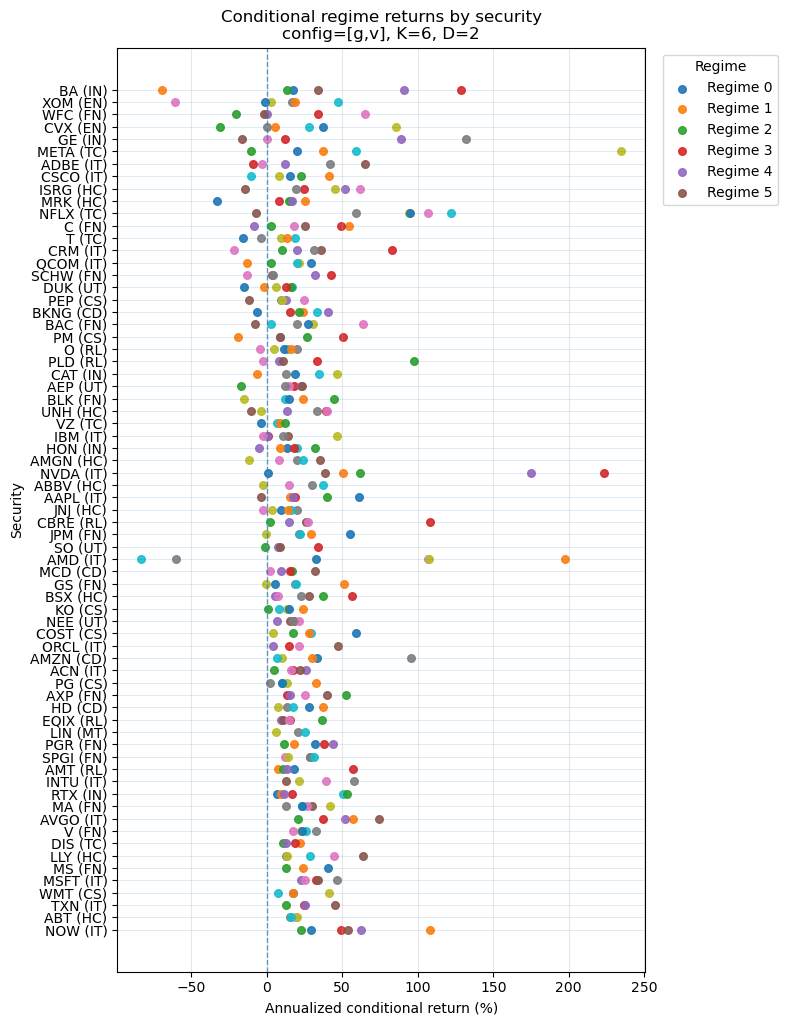

In [14]:
def plot_conditional_returns_all(
    securities,
    config,
    n_regimes,
    dim_latent,
    results_csv,
    segments_parquet,
    data_excel,
):
    """
    Horizontal scatter:
      y-axis: securities (exact order of `securities`, first at TOP)
      x-axis: annualized conditional return (%) for each regime
      one dot per regime per security, on a horizontal bar.
    """

    # --- Sector lookup from Excel ---
    static_df = pd.read_excel(
        data_excel,
        sheet_name="Static",
        usecols=[0, 1, 2],  # Ticker, Security, SectorID
    )
    # Map: Ticker -> SectorID
    sector_map = (
        static_df
        .set_index("Ticker")["SectorID"]
        .to_dict()
    )

    # Collect per-security regime tables into one DataFrame
    all_rows = []
    for sec in securities:
        tbl = regime_avg_return_table(
            security=sec,
            config=config,
            n_regimes=n_regimes,
            dim_latent=dim_latent,
            results_csv=results_csv,
            segments_parquet=segments_parquet,
        ).copy()
        tbl["security"] = sec
        all_rows.append(tbl)

    if not all_rows:
        raise ValueError("No securities provided for plotting.")

    df_all = pd.concat(all_rows, ignore_index=True)

    # Global x-range for the plot
    x_min = df_all["Ann Return (%)"].min()
    x_max = df_all["Ann Return (%)"].max()
    pad = 0.05 * (x_max - x_min if x_max > x_min else 1.0)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad

    regimes = sorted(df_all["Regime"].unique())

    fig_height = max(4, 0.15 * len(securities))
    fig, ax = plt.subplots(1, 1, figsize=(8, fig_height))

    # Draw one row per security, in the exact order given
    for y, sec in enumerate(securities):
        sub_sec = df_all[df_all["security"] == sec]
        if sub_sec.empty:
            continue

        # Horizontal bar (background line)
        ax.hlines(
            y,
            x_min_plot,
            x_max_plot,
            linewidth=0.5,
            alpha=0.2,
        )

        # Dots for each regime for this security
        for r in regimes:
            sub_r = sub_sec[sub_sec["Regime"] == r]
            if sub_r.empty:
                continue
            x = sub_r["Ann Return (%)"].iloc[0]
            ax.scatter(
                x,
                y,
                s=30,
                alpha=0.9,
                label=f"Regime {r}" if y == 0 else None,  # legend once
            )

    # Axis formatting
    ax.axvline(0.0, linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlim(x_min_plot, x_max_plot)
    ax.set_yticks(range(len(securities)))

    # Ticker + sector in parentheses
    yticklabels = []
    for sec in securities:
        sector = sector_map.get(sec)
        if sector:
            yticklabels.append(f"{sec} ({sector})")
        else:
            yticklabels.append(sec)
    ax.set_yticklabels(yticklabels)

    # Key line: first security at TOP, last at BOTTOM
    ax.invert_yaxis()

    ax.set_xlabel("Annualized conditional return (%)")
    ax.set_ylabel("Security")
    ax.set_title(
        f"Conditional regime returns by security\n"
        f"config={config}, K={n_regimes}, D={dim_latent}"
    )
    ax.grid(True, axis="x", alpha=0.3)
    ax.legend(title="Regime", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return df_all

df_conditional = plot_conditional_returns_all(
    securities=securities,
    config=config,
    n_regimes=n_regimes,
    dim_latent=dim_latent,
    results_csv=results_csv,
    segments_parquet=segments_parquet,
    data_excel=data_excel,
)


In [ ]:
# SCATTER PLOTS


In [ ]:
# CONFIG

start_date = "2017"
end_date = None

mode = "fund"   # px, fund, factor

# config = "[y]"
# n_regimes = 6
# dim_latent = 1

config = "[g,v]"
n_regimes = 6
dim_latent = 2

# config = "factor2_ff3"
# n_regimes = 4
# dim_latent = 3

value_sel = "cagr_rel_ex_ante"

In [ ]:
import numpy as np

def separation_metrics(ann_returns_pct):
    """
    ann_returns_pct: 1D array-like of conditional means (Ann Return (%)) for regimes.
    Returns range, min-gap-over-range, entropy of gaps, and a combined score.
    """
    m = np.sort(np.asarray(ann_returns_pct, dtype=float))
    if len(m) < 2:
        return {
            "range": np.nan,
            "min_gap_over_range": np.nan,
            "gap_entropy": np.nan,
            "combined_score": np.nan,
        }
    
    d = np.diff(m)
    R = m[-1] - m[0]
    if R <= 0:
        return {
            "range": 0.0,
            "min_gap_over_range": 0.0,
            "gap_entropy": 0.0,
            "combined_score": 0.0,
        }
    
    g = d / R
    g = g[g > 0]  # avoid log(0) if there are exact ties
    if len(g) == 0:
        return {
            "range": R,
            "min_gap_over_range": 0.0,
            "gap_entropy": 0.0,
            "combined_score": 0.0,
        }
    
    # min gap over range
    E_min = d[d > 0].min() / R

    # normalised entropy of gap distribution
    H = -np.sum(g * np.log(g))
    H_norm = H / np.log(len(g)) if len(g) > 1 else 0.0
    
    return {
        "range": R,
        "min_gap_over_range": E_min,
        "gap_entropy": H_norm,
        "combined_score": R * H_norm,
    }

def compute_all_metrics(
    securities,
    config,
    n_regimes,
    dim_latent,
    results_csv,
    segments_parquet,
):
    """
    For each security, compute regime_avg_return_table and then
    separation_metrics on the 'Ann Return (%)' column.
    Returns: dict {security -> metrics_dict}
    """
    all_metrics = {}
    for sec in securities:
        tbl = regime_avg_return_table(
            security=sec,
            config=config,
            n_regimes=n_regimes,
            dim_latent=dim_latent,
            results_csv=results_csv,
            segments_parquet=segments_parquet,
        )
        all_metrics[sec] = separation_metrics(tbl["Ann Return (%)"].values)
    return all_metrics

all_metrics = compute_all_metrics(
    securities=securities,
    config=config,
    n_regimes=n_regimes,
    dim_latent=dim_latent,
    results_csv=results_csv,
    segments_parquet=segments_parquet,
)



In [ ]:
import matplotlib.pyplot as plt

def plot_range_vs_cagr(
    securities,
    all_metrics,
    config,
    n_regimes,
    dim_latent,
    results_csv,
):
    """
    Scatter:
      x-axis: range = max(Ann Return (%)) - min(Ann Return (%))
      y-axis: cagr_rel (relative CAGR from results_csv, in %)
    One point per security.
    """

    # Load results once
    res = _load_results(results_csv)

    xs = []   # ranges
    ys = []   # relative CAGR
    labels = []

    for sec in securities:
        # Get range from precomputed metrics
        m = all_metrics.get(sec)
        if m is None:
            continue
        r = m["range"]  # in percentage points (Ann Return (%))

        # Get cagr_rel from results for this model/security
        row = _select_model_row(res, sec, config, n_regimes, dim_latent)
        cagr_rel = float(row["cagr_rel"])  # e.g. 0.12 for 12%

        xs.append(r)
        ys.append(cagr_rel * 100.0)  # convert to % for plotting
        labels.append(sec)

    if not xs:
        raise ValueError("No valid (range, cagr_rel) pairs to plot.")

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.scatter(xs, ys, s=30, alpha=0.8)

    # Optional: label points
    for x, y, sec in zip(xs, ys, labels):
        ax.annotate(sec, (x, y), xytext=(3, 3), textcoords="offset points", fontsize=7)

    ax.set_xlabel("Regime return range (max - min) in Ann Return (%)")
    ax.set_ylabel("Relative CAGR (%)")
    ax.set_title(
        f"Regime spread vs relative performance\n"
        f"config={config}, K={n_regimes}, D={dim_latent}"
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_range_vs_cagr(
    securities=securities,
    all_metrics=all_metrics,
    config=config,
    n_regimes=n_regimes,
    dim_latent=dim_latent,
    results_csv=results_csv,
)


In [ ]:
import matplotlib.pyplot as plt

def plot_min_vs_cagr(
    securities,
    config,
    n_regimes,
    dim_latent,
    results_csv,
    segments_parquet,
):
    """
    Scatter:
      x-axis: min(Ann Return (%)) across regimes
      y-axis: cagr_rel (relative CAGR from results_csv, in %)
    One point per security.
    """

    # Load results once
    res = _load_results(results_csv)

    xs = []   # min regime returns
    ys = []   # relative CAGR
    labels = []

    for sec in securities:
        # Get per-regime annualised returns
        tbl = regime_avg_return_table(
            security=sec,
            config=config,
            n_regimes=n_regimes,
            dim_latent=dim_latent,
            results_csv=results_csv,
            segments_parquet=segments_parquet,
        )

        min_r = float(tbl["Ann Return (%)"].min())  # x-axis

        # Get cagr_rel from results for this model/security
        row = _select_model_row(res, sec, config, n_regimes, dim_latent)
        cagr_rel = float(row["cagr_rel"])  # e.g. 0.12 for 12%

        xs.append(min_r)
        ys.append(cagr_rel * 100.0)  # convert to % for plotting
        labels.append(sec)

    if not xs:
        raise ValueError("No valid (min_regime_return, cagr_rel) pairs to plot.")

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.scatter(xs, ys, s=30, alpha=0.8)

    # Optional: label points
    for x, y, sec in zip(xs, ys, labels):
        ax.annotate(sec, (x, y), xytext=(3, 3), textcoords="offset points", fontsize=7)

    ax.set_xlabel("Min regime Ann Return (%)")
    ax.set_ylabel("Relative CAGR (%)")
    ax.set_title(
        f"Min regime return vs relative performance\n"
        f"config={config}, K={n_regimes}, D={dim_latent}"
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_min_vs_cagr(
    securities=securities,
    config=config,
    n_regimes=n_regimes,
    dim_latent=dim_latent,
    results_csv=results_csv,
    segments_parquet=segments_parquet,
)


In [ ]:
# New scatter plots

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_metric_vs_cagr(
    securities,
    all_metrics,
    config,
    n_regimes,
    dim_latent,
    results_csv,
    metric="range",  # e.g. "range", "gap_entropy", "min_gap_over_range", "combined_score"
):
    """
    Scatter + regression:
      x-axis: chosen metric from all_metrics[sec][metric]
      y-axis: cagr_rel (relative CAGR from results_csv, in %)
    One point per security.
    """

    # map aliases
    metric_key = metric
    if metric == "min_max":
        metric_key = "range"

    # Load results once
    res = _load_results(results_csv)

    xs = []
    ys = []
    labels = []

    for sec in securities:
        m = all_metrics.get(sec)
        if m is None:
            continue
        if metric_key not in m:
            raise KeyError(f"Metric '{metric_key}' not found in all_metrics for {sec}")

        x_val = float(m[metric_key])

        row = _select_model_row(res, sec, config, n_regimes, dim_latent)
        cagr_rel = float(row["cagr_rel"])  # in decimals

        xs.append(x_val)
        ys.append(cagr_rel * 100.0)  # convert to %
        labels.append(sec)

    if not xs:
        raise ValueError("No valid (metric, cagr_rel) pairs to plot.")

    df = pd.DataFrame({"x": xs, "y": ys, "security": labels})

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    # Scatter
    ax.scatter(df["x"], df["y"], s=30, alpha=0.8)

    # Regression line + CI band
    sns.regplot(
        data=df,
        x="x",
        y="y",
        ax=ax,
        ci=95,
        scatter=False,
        line_kws={"linewidth": 1.5},
    )

    # Labels on points
    for x, y, sec in zip(df["x"], df["y"], df["security"]):
        ax.annotate(sec, (x, y), xytext=(3, 3), textcoords="offset points", fontsize=7)

    # Axis label depending on metric
    metric_label_map = {
        "range": "Regime return range (max - min) in Ann Return (%)",
        "min_gap_over_range": "Min gap / range",
        "gap_entropy": "Gap entropy (H_norm)",
        "combined_score": "Range × entropy",
    }
    x_label = metric_label_map.get(metric_key, metric_key)

    ax.set_xlabel(x_label)
    ax.set_ylabel("Relative CAGR (%)")
    ax.set_title(
        f"Range vs Relative CAGR\n"
        #f"{metric_key} vs relative performance\n"
        f"config={config}, K={n_regimes}, D={dim_latent}"
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# Like your old plot_range_vs_cagr:
plot_metric_vs_cagr(
    securities=securities,
    all_metrics=all_metrics,
    config=config,
    n_regimes=n_regimes,
    dim_latent=dim_latent,
    results_csv=results_csv,
    metric="range",      # or "min_max"
)


In [ ]:
def plot_regime_stat_vs_cagr(
    securities,
    config,
    n_regimes,
    dim_latent,
    results_csv,
    segments_parquet,
    metric="min",  # "min", "max", "mean", "range", "entropy"
):
    """
    Scatter + regression:
      x-axis: chosen statistic of Ann Return (%) across regimes
      y-axis: cagr_rel (relative CAGR from results_csv, in %)
    One point per security.
    """

    # Load results once
    res = _load_results(results_csv)

    xs = []
    ys = []
    labels = []

    for sec in securities:
        tbl = regime_avg_return_table(
            security=sec,
            config=config,
            n_regimes=n_regimes,
            dim_latent=dim_latent,
            results_csv=results_csv,
            segments_parquet=segments_parquet,
        )

        arr = tbl["Ann Return (%)"].values.astype(float)

        if metric == "min":
            x_val = float(arr.min())
        elif metric == "max":
            x_val = float(arr.max())
        elif metric == "mean":
            x_val = float(arr.mean())
        elif metric in {"range", "min_max"}:
            x_val = float(arr.max() - arr.min())
        elif metric == "entropy":
            # reuse separation_metrics
            x_val = float(separation_metrics(arr)["gap_entropy"])
        else:
            raise ValueError(f"Unknown metric '{metric}'")

        row = _select_model_row(res, sec, config, n_regimes, dim_latent)
        cagr_rel = float(row["cagr_rel"])

        xs.append(x_val)
        ys.append(cagr_rel * 100.0)
        labels.append(sec)

    if not xs:
        raise ValueError("No valid (stat, cagr_rel) pairs to plot.")

    df = pd.DataFrame({"x": xs, "y": ys, "security": labels})

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    # Scatter
    ax.scatter(df["x"], df["y"], s=30, alpha=0.8)

    # Regression line + CI band
    sns.regplot(
        data=df,
        x="x",
        y="y",
        ax=ax,
        ci=95,
        scatter=False,
        line_kws={"linewidth": 1.5},
    )

    for x, y, sec in zip(df["x"], df["y"], df["security"]):
        ax.annotate(sec, (x, y), xytext=(3, 3), textcoords="offset points", fontsize=7)

    metric_label_map = {
        "min": "Min regime Ann Return (%)",
        "max": "Max regime Ann Return (%)",
        "mean": "Mean regime Ann Return (%)",
        "range": "Regime Ann Return range (max - min) (%)",
        "min_max": "Regime Ann Return range (max - min) (%)",
        "entropy": "Gap entropy (H_norm)",
    }
    x_label = metric_label_map.get(metric, metric)

    ax.set_xlabel(x_label)
    ax.set_ylabel("Relative CAGR (%)")
    ax.set_title(
        f"Min Regime Return vs Relative CAGR\n"
        # f"{metric} of regime returns vs relative performance\n"
        f"config={config}, K={n_regimes}, D={dim_latent}"
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# Your original min vs CAGR:
plot_regime_stat_vs_cagr(
    securities=securities,
    config=config,
    n_regimes=n_regimes,
    dim_latent=dim_latent,
    results_csv=results_csv,
    segments_parquet=segments_parquet,
    metric="min",
)

In [ ]:
# PERFORMANCE GROUPS

In [ ]:
import pandas as pd

# -------------------------------------------------------------------
# Parameters
# -------------------------------------------------------------------
FILE_NAME = "Findings/gridsearch_results_categories.xlsx"  # change path if needed

SHEETS = {
    "Y61":   "y61",
    "GV62":  "gv62",
    "FF3":   "ff3",
    "FFMOM": "ff3mom",
}

EXCELLENT_THRESHOLD = 0.05   # >= 5%
GOOD_THRESHOLD      = 0.02   # 2% to 5%
FAIR_THRESHOLD      = -0.02  # -2% to 2%
DENOMINATOR         = 75     # 75 stocks per model


def classify_cagr(x: float) -> str:
    if x >= EXCELLENT_THRESHOLD:
        return "Excellent"
    if GOOD_THRESHOLD <= x < EXCELLENT_THRESHOLD:
        return "Good"
    if FAIR_THRESHOLD <= x < GOOD_THRESHOLD:
        return "Fair"
    return "Poor"


def build_sector_table(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["rating"] = df["cagr_rel_ex_ante"].apply(classify_cagr)

    # counts by sector and rating
    counts = (
        df.groupby(["sector", "rating"])
          .size()
          .unstack(fill_value=0)
          .reindex(columns=["Excellent", "Good", "Fair", "Poor"])
          .reindex(["CD","CS","EN","FN","HC","IN","IT","MT","RL","TC","UT"])
    )

    # make sure count columns are ints
    counts[["Excellent", "Good", "Fair", "Poor"]] = \
        counts[["Excellent", "Good", "Fair", "Poor"]].astype(int)

    # percentages with denominator = 75 (decimals)
    pct = counts[["Excellent", "Good", "Fair", "Poor"]] / DENOMINATOR

    for col in ["Excellent", "Good", "Fair", "Poor"]:
        counts[col + "_pct"] = pct[col]

    return counts


# -------------------------------------------------------------------
# 1) OVERALL MODEL-LEVEL TABLE (counts + %)
# -------------------------------------------------------------------
summary_rows = []

for model_name, sheet_name in SHEETS.items():
    df = pd.read_excel(FILE_NAME, sheet_name=sheet_name)

    # assert: 75 unique stocks per model
    assert df.shape[0] <= DENOMINATOR, f"More than 75 rows in {sheet_name}"
    assert not df["security"].duplicated().any(), f"Duplicate securities in {sheet_name}"

    df["rating"] = df["cagr_rel_ex_ante"].apply(classify_cagr)

    counts = (
        df["rating"]
        .value_counts()
        .reindex(["Excellent", "Good", "Fair", "Poor"])
        .fillna(0)
        .astype(int)
    )
    pct = counts / DENOMINATOR

    row = {}
    for col in ["Excellent", "Good", "Fair", "Poor"]:
        row[col] = counts[col]
    for col in ["Excellent", "Good", "Fair", "Poor"]:
        row[col + "_pct"] = pct[col]

    summary_rows.append(pd.Series(row, name=model_name))

summary_table = pd.DataFrame(summary_rows)

# ensure count columns are ints
summary_table[["Excellent", "Good", "Fair", "Poor"]] = \
    summary_table[["Excellent", "Good", "Fair", "Poor"]].astype(int)

# -------------------------------------------------------------------
# 2–5) SECTOR-LEVEL TABLES (one per model, counts + %)
# -------------------------------------------------------------------
y61_sector   = build_sector_table(pd.read_excel(FILE_NAME, sheet_name="y61"))
gv62_sector  = build_sector_table(pd.read_excel(FILE_NAME, sheet_name="gv62"))
ff3_sector   = build_sector_table(pd.read_excel(FILE_NAME, sheet_name="ff3"))
ffmom_sector = build_sector_table(pd.read_excel(FILE_NAME, sheet_name="ff3mom"))

# -------------------------------------------------------------------
# Display the 5 tables: counts as int, % with 1 decimal
# -------------------------------------------------------------------
def format_pct(df: pd.DataFrame):
    pct_cols = [c for c in df.columns if c.endswith("_pct")]
    fmt = {c: "{:.1%}" for c in pct_cols}
    return df.style.format(fmt)

print("SUMMARY")
pct_cols_summary = ["Excellent_pct", "Good_pct", "Fair_pct", "Poor_pct"]
pct_format_summary = {col: "{:.1%}" for col in pct_cols_summary}
display(summary_table.style.format(pct_format_summary))

print("\nY61 BY SECTOR")
display(format_pct(y61_sector))

print("\nGV62 BY SECTOR ")
display(format_pct(gv62_sector))

print("\nFF3 BY SECTOR")
display(format_pct(ff3_sector))

print("\nFFMOM BY SECTOR")
display(format_pct(ffmom_sector))
